# Edge Transformer — Multi-N Curriculum Training

One set of weights trained on several graph sizes in **random cycle order**.
Because `proj_in = Linear(4, d)` the policy is fully size-agnostic, so after
training on `{5, 10, 13, 24}` we can probe it on unseen sizes like `{7, 12, 25}`
and see whether it has generalised.

Checkpoints saved to `./checkpoints_edge_multi_{checker_name}/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from turan_env_c import (
    CEnv,
    CHECKER_C3, CHECKER_C4, CHECKER_C3C4,
    CHECKER_K23, CHECKER_THETA123, CHECKER_BULL,
    CHECKER_BOWTIE, CHECKER_K4,
)
from edge_transformer_policy import EdgeTransformerPolicy
from ppo_edge import CFG, train_multi_n_random, load_checkpoint, run_episodes
from torch.optim import Adam

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")

/root/backtoRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch 2.10.0+cu130  cuda=True
  NVIDIA GeForce RTX 5090


## Pick your setup
Edit the two cells below, then run all.

In [ ]:
# ── CHANGE THESE ──────────────────────────────────────────────────────────────
CHECKER  = CHECKER_C3   # CHECKER_C3 | CHECKER_C4 | CHECKER_K4 | ...

TRAIN_NS = [20, 10, 13, 24]   # sizes the policy is trained on
EVAL_NS  = [7, 12, 25]       # held-out sizes — never seen during training

N_CYCLES         = 1         # how many times to cycle through TRAIN_NS (in random order)
STEPS_PER_N      = 3_000_000 # PPO steps per n per cycle

RESUME   = None              # e.g. './checkpoints_edge_multi_c3/final.pt'
TRAIN    = False

# Policy architecture
D_MODEL  = 128
N_HEADS  = 4
N_LAYERS = 2
# ──────────────────────────────────────────────────────────────────────────────

CHECKER_NAMES = {
    CHECKER_C3:       'c3',
    CHECKER_C4:       'c4',
    CHECKER_C3C4:     'c3c4',
    CHECKER_K23:      'k23',
    CHECKER_THETA123: 'theta123',
    CHECKER_BULL:     'bull',
    CHECKER_BOWTIE:   'bowtie',
    CHECKER_K4:       'k4',
}
checker_name = CHECKER_NAMES[CHECKER]
ckpt_dir     = f'./checkpoints_edge_multi_{checker_name}'

def mantel_bound(n):
    """ex(n, C3) = floor(n^2/4)  — rough reference for other checkers too."""
    return n * n // 4

print(f"Checker   : {checker_name}  (id={CHECKER})")
print(f"Train NS  : {TRAIN_NS}")
print(f"Eval  NS  : {EVAL_NS}")
print(f"Cycles    : {N_CYCLES}  x  {STEPS_PER_N/1e6:.1f}M steps/n")
print(f"Total     : ~{N_CYCLES * len(TRAIN_NS) * STEPS_PER_N / 1e6:.0f}M steps")
print(f"Ckpt dir  : {ckpt_dir}")
print(f"Policy    : d={D_MODEL}  heads={N_HEADS}  layers={N_LAYERS}")

Checker   : c3  (id=0)
Train NS  : [20, 10, 13, 24]
Eval  NS  : [7, 12, 25]
Cycles    : 1  x  3.0M steps/n
Total     : ~12M steps
Ckpt dir  : ./checkpoints_edge_multi_c3
Policy    : d=64  heads=4  layers=2


In [41]:
cfg = {**CFG}

cfg['checker_id']        = CHECKER
cfg['checkpoint_dir']    = ckpt_dir
cfg['total_steps_per_n'] = STEPS_PER_N

# Policy architecture
cfg['d_model']  = D_MODEL
cfg['n_heads']  = N_HEADS
cfg['n_layers'] = N_LAYERS

# ── PPO hyperparams ──
cfg['lr']          = 1e-5
cfg['ent_coef']    = 0.08
cfg['num_envs']    = 2048
cfg['n_steps']     = 64
cfg['batch_size']  = 2048
cfg['log_interval']  = 20
cfg['save_interval'] = 100
cfg['seed']          = 42

for k, v in cfg.items():
    print(f"  {k:22s} = {v}")

  n                      = 20
  num_envs               = 2048
  checker_id             = 0
  n_steps                = 64
  n_epochs               = 10
  batch_size             = 2048
  lr                     = 1e-05
  gamma                  = 0.99
  gae_lambda             = 0.95
  clip_eps               = 0.2
  vf_coef                = 0.5
  ent_coef               = 0.08
  max_grad_norm          = 0.5
  total_steps            = 20000000
  device                 = cuda
  log_interval           = 20
  save_interval          = 100
  checkpoint_dir         = ./checkpoints_edge_multi_c3
  total_steps_per_n      = 3000000
  d_model                = 64
  n_heads                = 4
  n_layers               = 2
  seed                   = 42


## Env sanity + benchmark

In [35]:
for n in TRAIN_NS:
    env = CEnv(n=n, num_envs=cfg['num_envs'], checker_id=CHECKER)
    obs = env.reset()
    E   = n * (n-1) // 2
    print(f"n={n:2d}  obs={obs.shape}  E={E:4d}  bound~{mantel_bound(n)}")
    env.close()

# Run timing benchmark on largest training size
env = CEnv(n=max(TRAIN_NS), num_envs=cfg['num_envs'], checker_id=CHECKER)
env.benchmark(steps=200)
env.close()

p = EdgeTransformerPolicy(D_MODEL, N_HEADS, N_LAYERS)
print(f"\nPolicy params: {sum(x.numel() for x in p.parameters()):,}")
del p

n=20  obs=(2048, 190)  E= 190  bound~100
n=10  obs=(2048, 45)  E=  45  bound~25
n=13  obs=(2048, 78)  E=  78  bound~42
n=24  obs=(2048, 276)  E= 276  bound~144
200 steps x 2048 envs in 0.01s
  36,025,560 steps/sec
  36.03M steps/sec

Policy params: 71,043


## Train

In [36]:
device = torch.device(cfg['device'])

if TRAIN:
    if RESUME:
        policy, optimizer, loaded_cfg, _, global_step, _ = load_checkpoint(RESUME, device=str(device))
        cfg.update({k: loaded_cfg[k] for k in ('d_model', 'n_heads', 'n_layers')})
        print(f"Resuming from {RESUME}  (global_step={global_step:,})")
    else:
        policy = EdgeTransformerPolicy(
            d_model  = cfg['d_model'],
            n_heads  = cfg['n_heads'],
            n_layers = cfg['n_layers'],
        ).to(device)
        policy    = torch.compile(policy)
        optimizer = Adam(policy.parameters(), lr=cfg['lr'])
        global_step = 0
        print(f"Fresh policy — {sum(p.numel() for p in policy.parameters()):,} params")

    policy, history = train_multi_n_random(
        train_ns    = TRAIN_NS,
        policy      = policy,
        optimizer   = optimizer,
        cfg         = cfg,
        n_cycles    = N_CYCLES,
        global_step = global_step,
    )
else:
    assert RESUME and os.path.exists(RESUME), \
        f"Set RESUME to a valid checkpoint path when TRAIN=False (got: {RESUME})"
    policy, _, cfg, _, _, _ = load_checkpoint(RESUME)
    policy.eval()
    history = []
    print(f"Loaded checkpoint: {RESUME} (training skipped)")

loaded ./checkpoints_edge_multi_c3/best_n24.pt  iter=22  steps=34,340,864  best=57.79
Loaded checkpoint: ./checkpoints_edge_multi_c3/best_n24.pt (training skipped)


## Training curves — per n

In [37]:
if not history:
    print("No history (loaded from checkpoint, skipping curves)")
else:
    # Split history by n
    by_n = defaultdict(list)
    for h in history:
        by_n[h['n']].append(h)

    colors = plt.cm.tab10.colors
    color_map = {n: colors[i % 10] for i, n in enumerate(TRAIN_NS)}

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    def smooth(vals, w=10):
        w = min(w, len(vals))
        return np.convolve(vals, np.ones(w)/w, mode='valid')

    # ── Return per n ──
    ax = axes[0, 0]
    for n, rows in sorted(by_n.items()):
        xs = [r['global_step'] / 1e6 for r in rows]
        ys = [r['mean_ret'] for r in rows]
        ax.plot(xs, ys, alpha=0.25, color=color_map[n])
        w = max(1, len(ys) // 15)
        ax.plot(xs[w-1:], smooth(ys, w), label=f'n={n} (bound~{mantel_bound(n)})',
                color=color_map[n], linewidth=2)
    ax.set_title('Return per n (smoothed)'); ax.set_xlabel('steps (M)'); ax.legend(fontsize=8)

    # ── Return normalised by Mantel bound ──
    ax = axes[0, 1]
    for n, rows in sorted(by_n.items()):
        xs  = [r['global_step'] / 1e6 for r in rows]
        ys  = [r['mean_ret'] / mantel_bound(n) for r in rows]
        w   = max(1, len(ys) // 15)
        ax.plot(xs[w-1:], smooth(ys, w), label=f'n={n}', color=color_map[n], linewidth=2)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='bound')
    ax.set_title('Return / Mantel bound'); ax.set_xlabel('steps (M)'); ax.legend(fontsize=8)

    # ── Policy loss ──
    ax = axes[0, 2]
    for n, rows in sorted(by_n.items()):
        xs = [r['global_step'] / 1e6 for r in rows]
        ys = [r['pg'] for r in rows]
        w  = max(1, len(ys) // 15)
        ax.plot(xs[w-1:], smooth(ys, w), label=f'n={n}', color=color_map[n])
    ax.set_title('Policy Loss'); ax.set_xlabel('steps (M)'); ax.legend(fontsize=8)

    # ── Entropy ──
    ax = axes[1, 0]
    for n, rows in sorted(by_n.items()):
        xs = [r['global_step'] / 1e6 for r in rows]
        ys = [r['ent'] for r in rows]
        w  = max(1, len(ys) // 15)
        ax.plot(xs[w-1:], smooth(ys, w), label=f'n={n}', color=color_map[n])
    ax.set_title('Entropy'); ax.set_xlabel('steps (M)'); ax.legend(fontsize=8)

    # ── FPS ──
    ax = axes[1, 1]
    all_xs  = [h['global_step'] / 1e6 for h in history]
    all_fps = [h['fps'] for h in history]
    ax.scatter(all_xs, all_fps, s=2, alpha=0.4,
               c=[color_map[h['n']] for h in history])
    ax.set_title('FPS (colour = n)'); ax.set_xlabel('steps (M)')

    # ── Best return per n summary ──
    ax = axes[1, 2]
    ns_sorted   = sorted(by_n.keys())
    best_rets   = [max(r['mean_ret'] for r in by_n[n]) for n in ns_sorted]
    bounds_plot = [mantel_bound(n) for n in ns_sorted]
    x_pos = np.arange(len(ns_sorted))
    ax.bar(x_pos, best_rets,   label='best return', color=[color_map[n] for n in ns_sorted], alpha=0.8)
    ax.bar(x_pos, bounds_plot, label='Mantel bound', fill=False, edgecolor='red', linewidth=2)
    ax.set_xticks(x_pos); ax.set_xticklabels([f'n={n}' for n in ns_sorted])
    ax.set_title('Best return vs bound'); ax.legend(fontsize=8)

    total_steps = history[-1]['global_step'] / 1e6
    plt.suptitle(
        f'EdgeTransformer Multi-N — {checker_name.upper()}  '
        f'train={TRAIN_NS}  {total_steps:.0f}M steps  '
        f'{N_CYCLES} cycles',
        fontsize=12)
    plt.tight_layout()
    plt.show()

No history (loaded from checkpoint, skipping curves)


## Evaluate — training sizes and held-out sizes

Run the **same trained policy** deterministically on all sizes (train + eval).
Held-out sizes were never seen during training.

In [38]:
import networkx as nx

policy.eval()
N_EVAL_EPISODES = 32
all_ns = sorted(set(TRAIN_NS) | set(EVAL_NS))

results = {}
print(f"{'n':>4}  {'seen':>6}  {'best_edges':>10}  {'bound':>6}  {'%bound':>7}")
print('-' * 42)
for n in all_ns:
    seen  = 'train' if n in TRAIN_NS else 'HELD-OUT'
    adjs  = run_episodes(policy, {**cfg, 'n': n}, n_episodes=N_EVAL_EPISODES, deterministic=True)
    edges = [int(adj.sum()) // 2 for adj in adjs]
    best  = max(edges)
    bound = mantel_bound(n)
    pct   = best / bound * 100
    results[n] = dict(best=best, bound=bound, pct=pct, adjs=adjs, edges=edges)
    print(f"{n:>4}  {seen:>8}  {best:>10}  {bound:>6}  {pct:>6.1f}%")

   n    seen  best_edges   bound   %bound
------------------------------------------
   7  HELD-OUT           6      12    50.0%


  10     train          11      25    44.0%
  12  HELD-OUT          16      36    44.4%
  13     train          18      42    42.9%
  20     train          41     100    41.0%
  24     train          56     144    38.9%
  25  HELD-OUT          61     156    39.1%


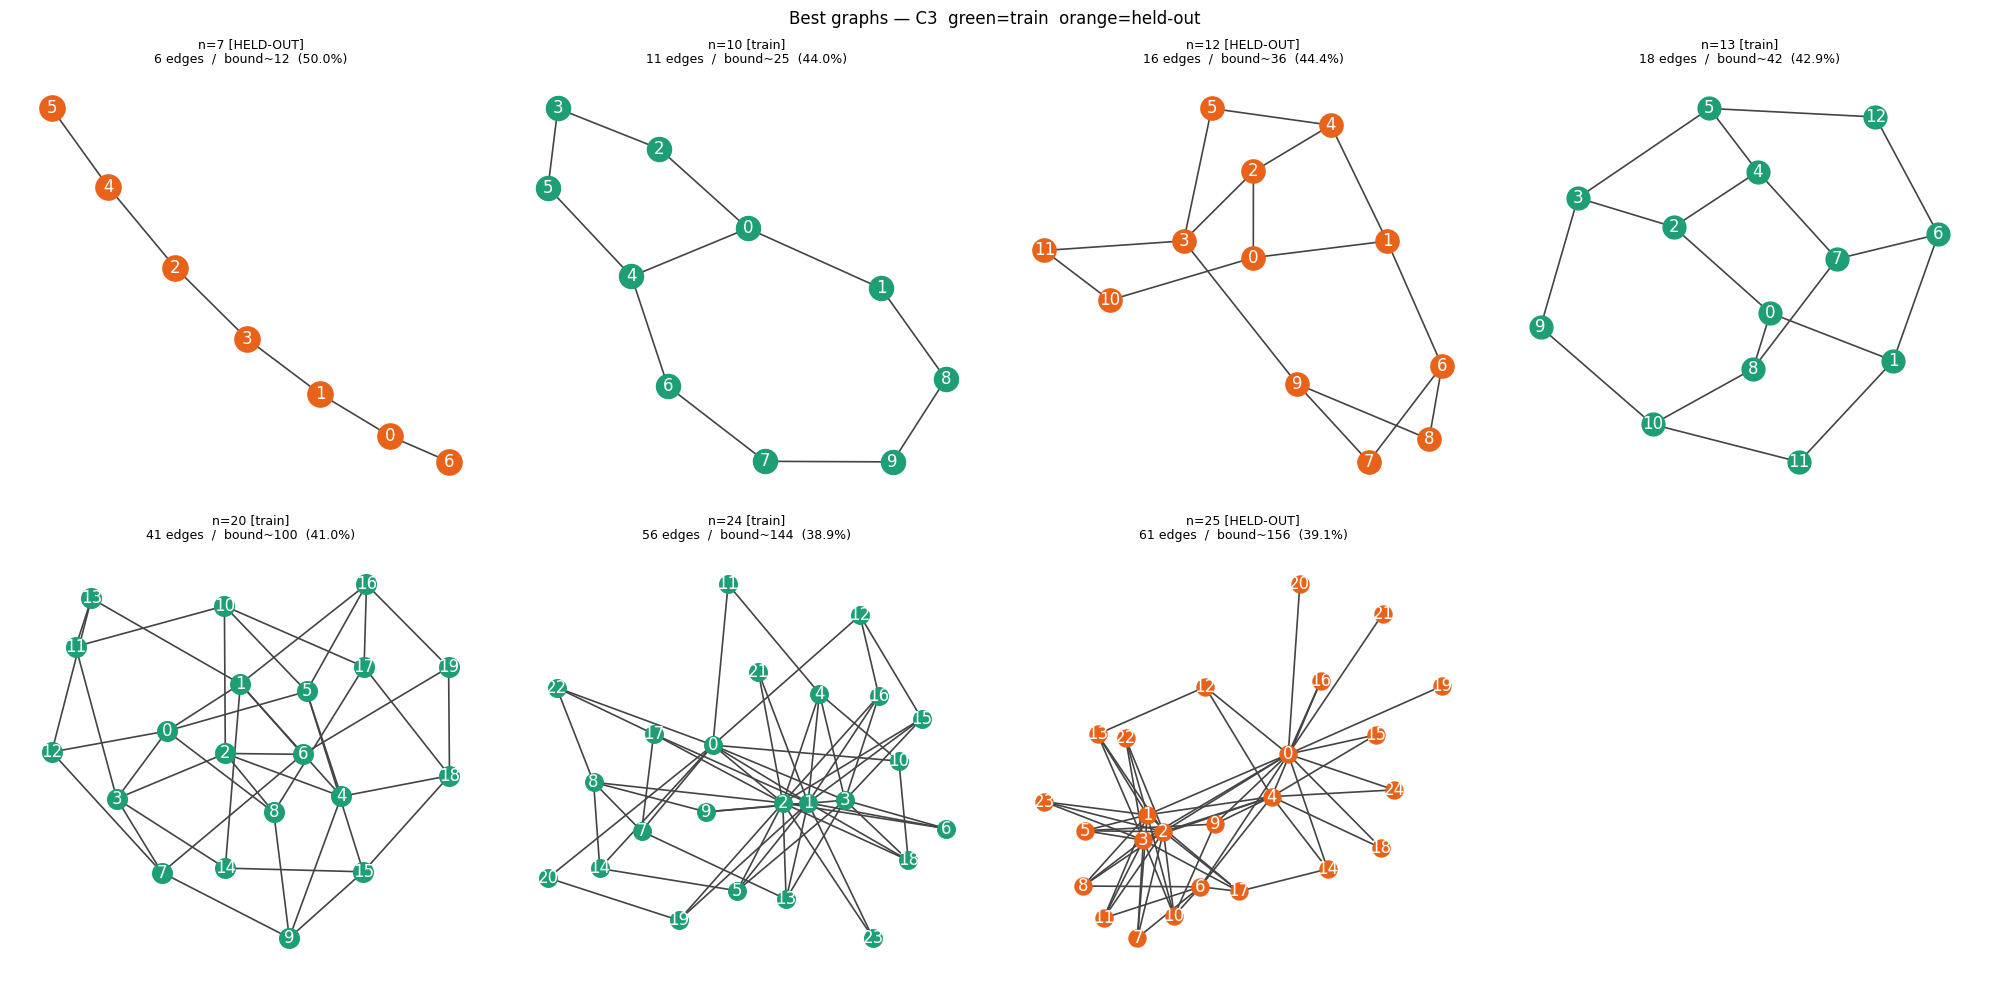

In [39]:
# Draw best graph for each eval size
n_cols  = min(len(all_ns), 4)
n_rows  = (len(all_ns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for idx, n in enumerate(all_ns):
    r    = results[n]
    best_adj = r['adjs'][np.argmax(r['edges'])]
    G   = nx.from_numpy_array(best_adj)
    pos = nx.spring_layout(G, seed=42)
    color = '#1D9E75' if n in TRAIN_NS else '#E8621A'
    nx.draw(G, pos, ax=axes[idx], with_labels=True,
            node_color=color, node_size=max(50, 400 - n * 10),
            font_color='white', edge_color='#444', width=1.2)
    label = 'train' if n in TRAIN_NS else 'HELD-OUT'
    axes[idx].set_title(
        f"n={n} [{label}]\n{r['best']} edges  /  bound~{r['bound']}  ({r['pct']:.1f}%)",
        fontsize=9)

for ax in axes[len(all_ns):]:
    ax.axis('off')

plt.suptitle(
    f'Best graphs — {checker_name.upper()}  '
    f'green=train  orange=held-out',
    fontsize=12)
plt.tight_layout()
plt.show()